# Partie 1

In [1]:
!pip install category_encoders


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from category_encoders.binary import BinaryEncoder


In [3]:

# 1. Charger les données
df = pd.read_csv("clients_lab.csv")

# 2. Séparer `nom_complet` en `prenom` et `nom`
df[['prenom', 'nom']] = df['nom_complet'].str.split(' ', n=1, expand=True)

# 3. Extraire la ville depuis `adresse`: Trouver une séquence de 5 chiffres (le code postal), suivie d’au moins un espace, puis extraire tout le reste (le nom de la ville)
df['ville'] = df['adresse'].str.extract(r'\d{5}\s+(.+)$')

df[['nom_complet', 'prenom', 'nom', 'adresse','ville']].head()


,nom_complet,prenom,nom,adresse,ville
0,Mathilde Benoit,Mathilde,Benoit,"444, rue Henry, 00816 Gilles-sur-Boulanger",Gilles-sur-Boulanger
1,Tristan Lesage,Tristan,Lesage,"8, chemin de Charpentier, 09672 Sainte Émilie-...",Sainte Émilie-la-Forêt
2,Tristan Boutin,Tristan,Boutin,"84, avenue Toussaint, 64092 Fischer-sur-Gautier",Fischer-sur-Gautier
3,William-Alain Girard,William-Alain,Girard,"32, chemin de Alexandre, 62783 Bigot",Bigot
4,Alfred du Gimenez,Alfred,du Gimenez,"46, rue Lesage, 20085 LaineBourg",LaineBourg


In [4]:

# 4. Créer `age_groupe`
df['age_groupe'] = pd.cut(df['age'], bins=[17, 30, 60, 100], labels=['Jeune', 'Adulte', 'Senior'])
df[['age','age_groupe']].head()

,age,age_groupe
0,52,Adulte
1,77,Senior
2,18,Jeune
3,54,Adulte
4,50,Adulte


In [5]:

# 5. Discrétiser `revenu_mensuel` en quartiles
df['revenu_quartile'] = pd.qcut(df['revenu_mensuel'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df[['revenu_mensuel','revenu_quartile']].head()

,revenu_mensuel,revenu_quartile
0,3791.07,Q4
1,2788.56,Q2
2,2684.59,Q2
3,3384.79,Q3
4,3318.88,Q3


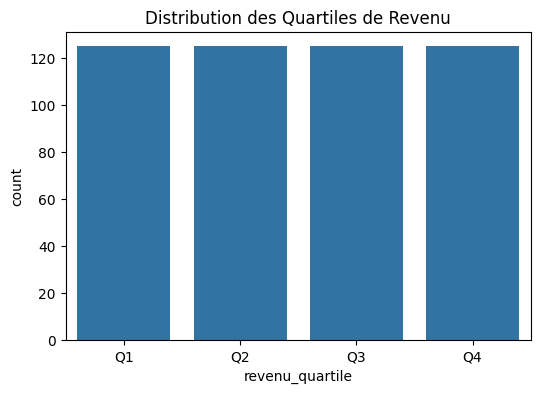

In [6]:
# Visualiser la répartition des quartiles
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='revenu_quartile')
plt.title("Distribution des Quartiles de Revenu")
plt.show()

In [7]:
# 6. Extraire année, mois, jour de la semaine depuis `date_achat`
df['date_achat'] = pd.to_datetime(df['date_achat'])
df['annee_achat'] = df['date_achat'].dt.year
df['mois_achat'] = df['date_achat'].dt.month
df['jour_semaine'] = df['date_achat'].dt.day_name()

df[['date_achat','annee_achat','mois_achat','jour_semaine']].head()

,date_achat,annee_achat,mois_achat,jour_semaine
0,2024-01-07,2024,1,Sunday
1,2023-10-21,2023,10,Saturday
2,2023-09-12,2023,9,Tuesday
3,2024-10-31,2024,10,Thursday
4,2024-01-23,2024,1,Tuesday


In [8]:
# 7. Regrouper professions peu fréquentes
freq = df['profession'].value_counts()
to_keep = freq[freq > 30].index
df['profession_grp'] = df['profession'].where(df['profession'].isin(to_keep), 'autre')

print("Professions uniques dans 'profession':")
print(df['profession'].unique())

print("\nProfessions après regroupement dans 'profession_grp':")
print(df['profession_grp'].unique())

print("\nFréquence des professions d'origine :")
print(df['profession'].value_counts())

print("\nFréquence des professions regroupées :")
print(df['profession_grp'].value_counts())


df[['profession','profession_grp']].head()



Professions uniques dans 'profession':
['étudiant' 'retraité' 'autre' 'ingénieur' 'médecin' 'comptable'
 'enseignant' 'ouvrier']

Professions après regroupement dans 'profession_grp':
['étudiant' 'retraité' 'autre' 'ingénieur' 'médecin' 'comptable'
 'enseignant' 'ouvrier']

Fréquence des professions d'origine :
profession
ouvrier       67
retraité      65
ingénieur     64
comptable     63
médecin       62
autre         62
enseignant    59
étudiant      58
Name: count, dtype: int64

Fréquence des professions regroupées :
profession_grp
ouvrier       67
retraité      65
ingénieur     64
comptable     63
médecin       62
autre         62
enseignant    59
étudiant      58
Name: count, dtype: int64


,profession,profession_grp
0,étudiant,étudiant
1,retraité,retraité
2,autre,autre
3,ingénieur,ingénieur
4,étudiant,étudiant


**Conclusion:** le regroupement n’a rien changé dans ce cas, car aucune profession n’était "peu fréquente" selon ton seuil (>30).

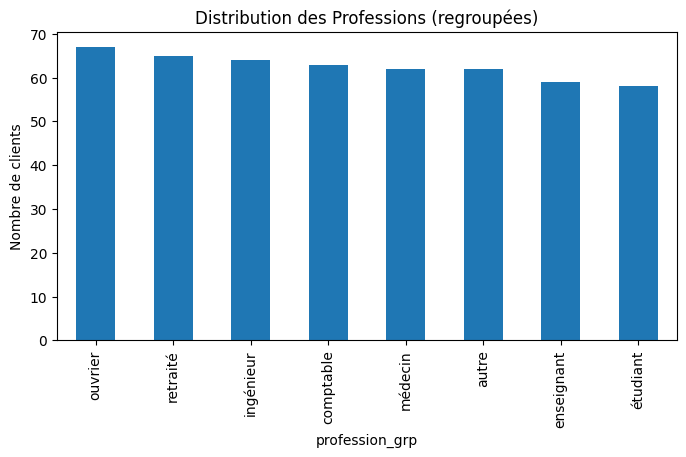

In [9]:

# Visualiser la fréquence des professions
plt.figure(figsize=(8,4))
df['profession_grp'].value_counts().plot(kind='bar')
plt.title("Distribution des Professions (regroupées)")
plt.ylabel("Nombre de clients")
plt.show()

In [10]:
# One-Hot pour sexe
sexe_encoded = pd.get_dummies(df['sexe'], prefix='sexe')

# One-Hot pour profession (ou profession_grp)
profession_encoded = pd.get_dummies(df['profession'], prefix='profession')

# Fusionner avec le DataFrame d'origine
df = pd.concat([df, sexe_encoded, profession_encoded], axis=1)

df[['sexe', 'profession'] + list(sexe_encoded.columns) + list(profession_encoded.columns)].head()

,sexe,profession,sexe_F,sexe_M,profession_autre,profession_comptable,profession_enseignant,profession_ingénieur,profession_médecin,profession_ouvrier,profession_retraité,profession_étudiant
0,F,étudiant,True,False,False,False,False,False,False,False,False,True
1,F,retraité,True,False,False,False,False,False,False,False,True,False
2,M,autre,False,True,True,False,False,False,False,False,False,False
3,F,ingénieur,True,False,False,False,False,True,False,False,False,False
4,M,étudiant,False,True,False,False,False,False,False,False,False,True


In [11]:
# 8. Encodage de 'produit' en binaire

import pandas as pd

# Étape 1 : extraire la partie numérique
df['produit_code'] = df['produit'].str.extract(r'(\d+)')
df['produit_code'] = pd.to_numeric(df['produit_code'], errors='coerce')

# Étape 2 : encoder proprement en binaire (avec au moins 10 bits pour les grands codes)
def to_binary_str(val):
    if pd.notnull(val):
        return format(int(val), '010b')  # 10 bits
    else:
        return '0000000000'

df['produit_bin'] = df['produit_code'].apply(to_binary_str)

# Étape 3 : découper les bits de manière sécurisée
produit_bin_df = df['produit_bin'].apply(lambda x: pd.Series(list(str(x)))).fillna('0')
produit_bin_df.columns = [f'produit_bit_{i}' for i in range(produit_bin_df.shape[1])]
produit_bin_df = produit_bin_df.astype(int)

# Étape 4 : concaténer avec le DataFrame original
df = pd.concat([df, produit_bin_df], axis=1)


df[['produit', 'produit_code', 'produit_bin'] + list(produit_bin_df.columns)].head(10)



,produit,produit_code,produit_bin,produit_bit_0,produit_bit_1,produit_bit_2,produit_bit_3,produit_bit_4,produit_bit_5,produit_bit_6,produit_bit_7,produit_bit_8,produit_bit_9
0,D171,171,0010101011,0,0,1,0,1,0,1,0,1,1
1,B222,222,0011011110,0,0,1,1,0,1,1,1,1,0
2,D540,540,1000011100,1,0,0,0,0,1,1,1,0,0
3,C922,922,1110011010,1,1,1,0,0,1,1,0,1,0
4,C106,106,0001101010,0,0,0,1,1,0,1,0,1,0
5,A517,517,1000000101,1,0,0,0,0,0,0,1,0,1
6,C226,226,0011100010,0,0,1,1,1,0,0,0,1,0
7,C966,966,1111000110,1,1,1,1,0,0,0,1,1,0
8,D796,796,1100011100,1,1,0,0,0,1,1,1,0,0
9,D236,236,0011101100,0,0,1,1,1,0,1,1,0,0


# Partie 2

In [12]:
# 9. Prédiction : prétraitement + modèles


from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Cible à prédire
y = df['achat']

# Liste des variables à utiliser


# Variables numériques brutes
numeric_features = ['age', 'revenu_mensuel']

# Variables catégorielles à encoder
# On choisit `profession_grp` (version regroupée) au lieu de `profession` pour éviter trop de colonnes One-Hot
# On inclut les variables extraites de date (mois, jour de semaine), la ville, l’âge groupe
categorical_features = [
    'sexe', 'profession_grp', 'ville', 'age_groupe',
    'mois_achat', 'jour_semaine'
]

# Colonnes binaires extraites de 'produit' déjà encodées sous forme 0/1
binary_features = [f'produit_bit_{i}' for i in range(10)]

# Finalement, on ne garde **pas** :
# - nom_complet, nom, prénom (peu pertinents pour la prédiction)
# - adresse, date_achat (déjà transformées)
# - revenu_quartile, age_groupe (doublon avec les variables continues)

# Données categorielle
X = df[numeric_features + categorical_features + binary_features]



# Préprocesseur général
preprocessor = ColumnTransformer([
    # Imputation + standardisation pour les numériques
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_features),

    # Imputation + OneHotEncoder pour les catégorielles
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features),

    # Passage direct des colonnes binaires déjà prêtes
    ('bin', 'passthrough', binary_features)
])

# Pipelines de modèles
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    print(f"============= Modèle : {name} ================")

    # Pipeline avec prétraitement
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])

    # Validation croisée avec pipeline complet
    scores = cross_val_score(pipeline, X, y, cv=cv)
    print("Avec prétraitement :")
    print("Scores par fold :", scores)
    print("Moyenne :", round(scores.mean(), 4))
    print("Écart-type :", round(scores.std(), 4))

    # Pipeline brut (sans preprocessing) : il faut encoder manuellement les colonnes catégorielles
    X_brut = X.copy()
    X_brut[categorical_features] = X_brut[categorical_features].astype(str)
    X_brut_encoded = pd.get_dummies(X_brut, drop_first=True)

    scores_brut = cross_val_score(model, X_brut_encoded, y, cv=cv)
    print("Sans prétraitement :")
    print("Scores par fold :", scores_brut)
    print("Moyenne :", round(scores_brut.mean(), 4))
    print("Écart-type :", round(scores_brut.std(), 4))


============= Modèle : KNN ================
Avec prétraitement :
Scores par fold : [0.48 0.52 0.39 0.49 0.47]
Moyenne : 0.47
Écart-type : 0.0434
Sans prétraitement :
Scores par fold : [0.52 0.51 0.47 0.6  0.54]
Moyenne : 0.528
Écart-type : 0.0426
============= Modèle : Decision Tree ================
Avec prétraitement :
Scores par fold : [0.51 0.56 0.48 0.53 0.56]
Moyenne : 0.528
Écart-type : 0.0306
Sans prétraitement :
Scores par fold : [0.52 0.55 0.53 0.52 0.5 ]
Moyenne : 0.524
Écart-type : 0.0162
